# Revised EDA

## Module Imports

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

## Data Import

In [3]:
chunksFilePath = Path("GlobalGeoTree-6M/Chunks1Pixel/")

df = torch.load(chunksFilePath / 'SampledData-10Percent.pth', map_location="cpu", weights_only=False)

In [4]:
df.columns

Index(['ID', 'longitude', 'latitude', 'elevation', 'slope', 'aspect',
       'soil_moisture_0_5cm', 'soil_moisture_5_15cm', 'soil_moisture_15_30cm',
       'bio01', 'bio02', 'bio03', 'bio04', 'bio05', 'bio06', 'bio07', 'bio08',
       'bio09', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16',
       'bio17', 'bio18', 'bio19', 'level0', 'level1_family', 'level2_genus',
       'imgData', 'level3_species'],
      dtype='object')

# Hierarchy
- Count unique values of levels 0, 1, 2, 3

In [5]:
levels = [col for col in df.columns if 'level' in col]
valueCounts = []

for level in levels:
    vc = df[level].value_counts().reset_index()
    vc.columns = [level, 'count']
    vc['level'] = level
    valueCounts.append(vc)

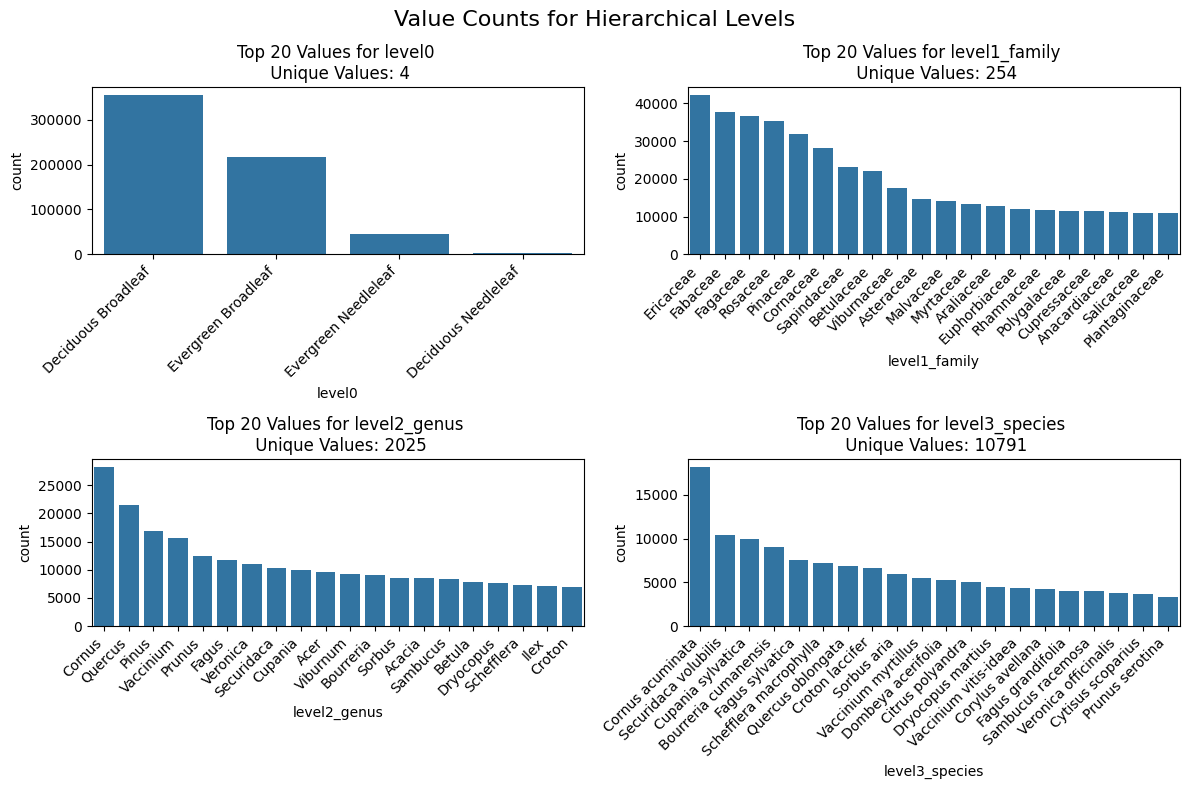

In [6]:
# plot top 20 values for each level

figHi, axHi = plt.subplots(2, 2, figsize=(6 * 2, 4*2))

for i, vc in enumerate(valueCounts):
    a = i // 2
    b = i % 2
    sns.barplot(data=vc.head(20), y='count', x=vc.columns[0], ax=axHi[a, b])
    axHi[a, b].set_title(f'Top 20 Values for {vc.columns[0]} \n Unique Values: {vc.shape[0]}')
    axHi[a, b].tick_params(axis='x', rotation=45)
    for label in axHi[a, b].get_xticklabels():
        label.set_horizontalalignment('right')
        label.set_verticalalignment('top')

figHi.suptitle('Value Counts for Hierarchical Levels', fontsize=16)
figHi.tight_layout()

- Very significant class imbalances
- Signifcantly more unique groups in higher classification levels

In [7]:
# minimum value frequency per level
for vc in valueCounts:
    min_count = vc['count'].min()
    level = vc['level'].iloc[0]
    print(f"Minimum frequency for {level}: {min_count}, occurrences: {vc[vc['count'] == min_count].shape[0]}")

Minimum frequency for level0: 2453, occurrences: 1
Minimum frequency for level1_family: 1, occurrences: 16
Minimum frequency for level2_genus: 1, occurrences: 318
Minimum frequency for level3_species: 1, occurrences: 3074


~30% of species only have a single observation - this is going to be a big problem

In [8]:
# Verify hierarchy - check that each level uniquely maps to parent levels
hierarchy_issues = []

# Assuming order: level1 -> level2 -> level3 -> level4 (if it exists)
level_cols = sorted([col for col in df.columns if 'level' in col])

for i in range(1, len(level_cols)):
    lower_level = level_cols[i]
    upper_level = level_cols[i-1]
    
    # Group by lower level and check if upper level is unique
    mapping = df.groupby(lower_level)[upper_level].nunique()
    violations = mapping[mapping > 1]
    
    if len(violations) > 0:
        hierarchy_issues.append(f"{lower_level} -> {upper_level}: {len(violations)} violations")
        print(f"{lower_level} does NOT uniquely map to {upper_level}")
        print(violations.head())
    else:
        print(f"{lower_level} uniquely maps to {upper_level}")

if not hierarchy_issues:
    print("\nHierarchy is valid - each level uniquely identifies its parent level(s)")
else:
    print(f"\nFound {len(hierarchy_issues)} hierarchy issues")


level1_family does NOT uniquely map to level0
level1_family
Acanthaceae      2
Actinidiaceae    2
Akaniaceae       2
Amaranthaceae    2
Anacardiaceae    2
Name: level0, dtype: int64
level2_genus does NOT uniquely map to level1_family
level2_genus
Bourreria    2
Name: level1_family, dtype: int64
level3_species uniquely maps to level2_genus

Found 2 hierarchy issues


In [9]:
dfBou = df[df['level2_genus'] == 'Bourreria']

dfBou[levels].value_counts()

level0               level1_family  level2_genus  level3_species      
Evergreen Broadleaf  Boraginaceae   Bourreria     Bourreria cumanensis    8992
                     Ehretiaceae    Bourreria     Bourreria exsucca         68
                                                  Bourreria succulenta       3
Name: count, dtype: int64

Confirms hierarchy issues are present

# Missingness

## ID and Labels

In [10]:
df['ID'].isna().sum(axis=0)

np.int64(0)

In [11]:
df[levels].isna().sum(axis=0)

level0            0
level1_family     0
level2_genus      0
level3_species    0
dtype: int64

No missing data from ID and labels = Good

## Numeric Predictors

In [12]:
numericCols = [col for col in df.columns if col not in levels + ['ID', 'imgData']]

featureMissing = df[numericCols].isna().sum(axis=0)
rowMissing = df[numericCols].isna().sum(axis=1)/df[numericCols].shape[1]
rowMissingNo0 = rowMissing[rowMissing != 0.0]


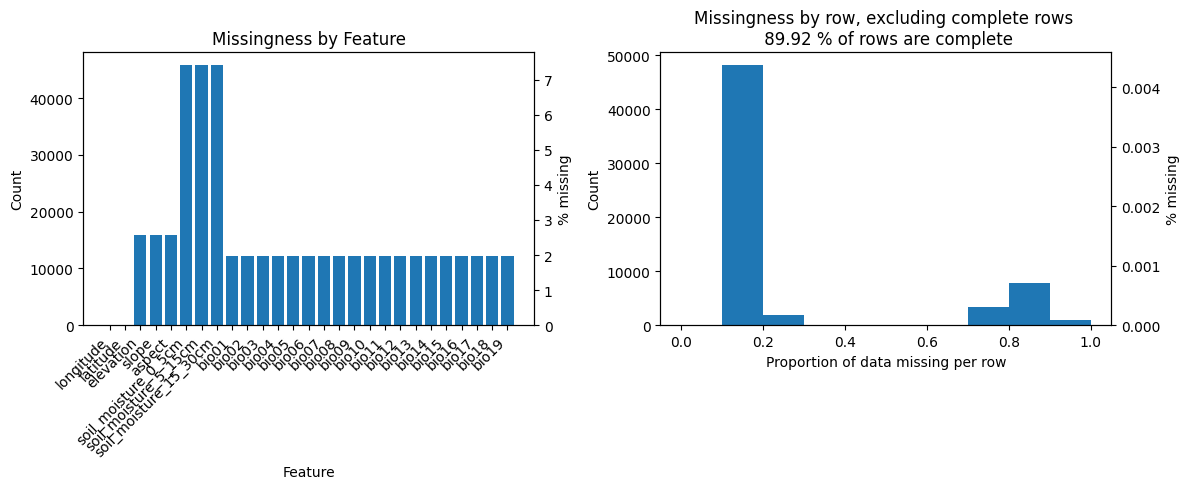

In [13]:
figMis, axMis = plt.subplots(ncols=2, figsize = (12, 5))

# Left subplot: counts
axMis[0].bar(featureMissing.index, featureMissing.values, color='tab:blue')
axMis[0].set_title('Missingness by Feature')
axMis[0].set_ylabel('Count')
axMis[0].set_xlabel('Feature')
axMis[0].tick_params(axis='x', rotation=45)
for label in axMis[0].get_xticklabels():
    label.set_horizontalalignment('right')
    label.set_verticalalignment('top')

# Secondary y-axis for % missing (no additional plot)
featureMissingPct = featureMissing / len(df) * 100
ax_right = axMis[0].twinx()
ax_right.set_ylabel('% missing')
ax_right.grid(False)
# Optional: align y-limits to percentage scale only
ax_right.set_ylim(0, featureMissingPct.max() * 1.05 if len(featureMissingPct) else 1)

misBins = np.arange(0, 1.1, 0.1)
axMis[1].hist(rowMissingNo0.values, bins=misBins)
axMis[1].set_title(f'Missingness by row, excluding complete rows \n {rowMissing[rowMissing==0].shape[0]/df.shape[0]*100:.2f} % of rows are complete')
axMis[1].set_ylabel('Count')
axMis[1].set_xlabel('Proportion of data missing per row')

# Secondary y-axis for % missing (no additional plot)
rowMissingPct = df[numericCols].isna().sum(axis=1)/df.shape[0] * 100
ax_right = axMis[1].twinx()
ax_right.set_ylabel('% missing')
ax_right.grid(False)
# Optional: align y-limits to percentage scale only
ax_right.set_ylim(0, rowMissingPct.max() * 1.05 if len(rowMissingPct) else 1)




figMis.tight_layout()

- ~90% of rows are complete
- small proportion of rows have signifcant missingness, large proprtion have small missingness

## Image Data

### How many images have missing data

In [14]:
def nan_check(t):
    if isinstance(t, torch.Tensor) and t.is_floating_point():
        if torch.isnan(t).sum().item() > 0:
            return 1
    return 0

df['img_has_nan'] = df['imgData'].apply(nan_check)
df['img_has_nan'].describe()

count    617620.000000
mean          0.659721
std           0.473803
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: img_has_nan, dtype: float64

- 66% of rows have some level of missing image data
- this is a big problem :(

In [15]:
def nanProp(t):
    if isinstance(t, torch.Tensor) and t.is_floating_point():
        return torch.isnan(t).sum().item()/120
    return 0

df['img_nan_prop'] = df['imgData'].apply(nanProp)
df['img_nan_prop'].describe()

count    617620.000000
mean          0.118960
std           0.138493
min           0.000000
25%           0.000000
50%           0.083333
75%           0.166667
max           1.000000
Name: img_nan_prop, dtype: float64

Text(0, 0.5, 'Count (log scale)')

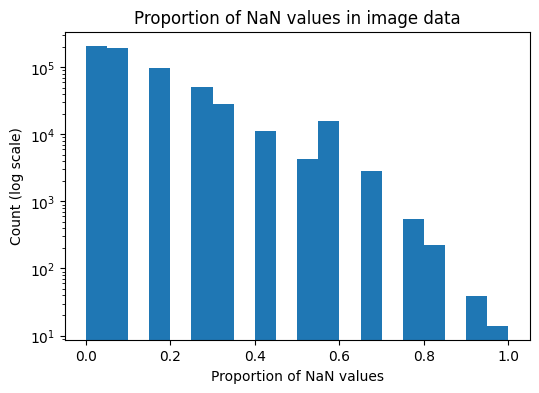

In [18]:
figImgNan, axImgNan = plt.subplots(figsize=(6,4))

axImgNan.hist(df['img_nan_prop'].values, bins=np.arange(0, 1.05, 0.05))
axImgNan.set_title('Proportion of NaN values in image data')

axImgNan.set_yscale('log')
axImgNan.set_xlabel('Proportion of NaN values')
axImgNan.set_ylabel('Count (log scale)')

In [21]:
# proportion of rows with more than 50% NaN in image data
propMoreThanHalfNan = (df['img_nan_prop'] > 0.5).sum()/df.shape[0]
print(f"Proportion of rows with more than 50% NaN in image data: {propMoreThanHalfNan*100:.2f}%")

Proportion of rows with more than 50% NaN in image data: 3.14%


That is far more acceptable to drop

In [26]:
# check also if any rows have NaN for all months in a single band

def nanBand(t):
    '''returns how many months have data missing for all bands'''
    if isinstance(t, torch.Tensor) and t.is_floating_point():
        return torch.isnan(t).sum(axis=0).max().item()
    return 0

df['img_nan_band'] = df['imgData'].apply(nanBand)
df['img_nan_band'].describe()

count    617620.000000
mean          1.427519
std           1.661921
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          12.000000
Name: img_nan_band, dtype: float64

In [27]:
df['img_nan_band'].value_counts()

img_nan_band
0     210163
1     193590
2      99225
3      51629
4      28141
7      15724
5      11268
6       4227
8       2820
9        554
10       226
11        39
12        14
Name: count, dtype: int64

- Very small number of rows have a band missing for all 12 months, this is good and we will discard those which are fully missing

# Distributions

## Numeric Predictors

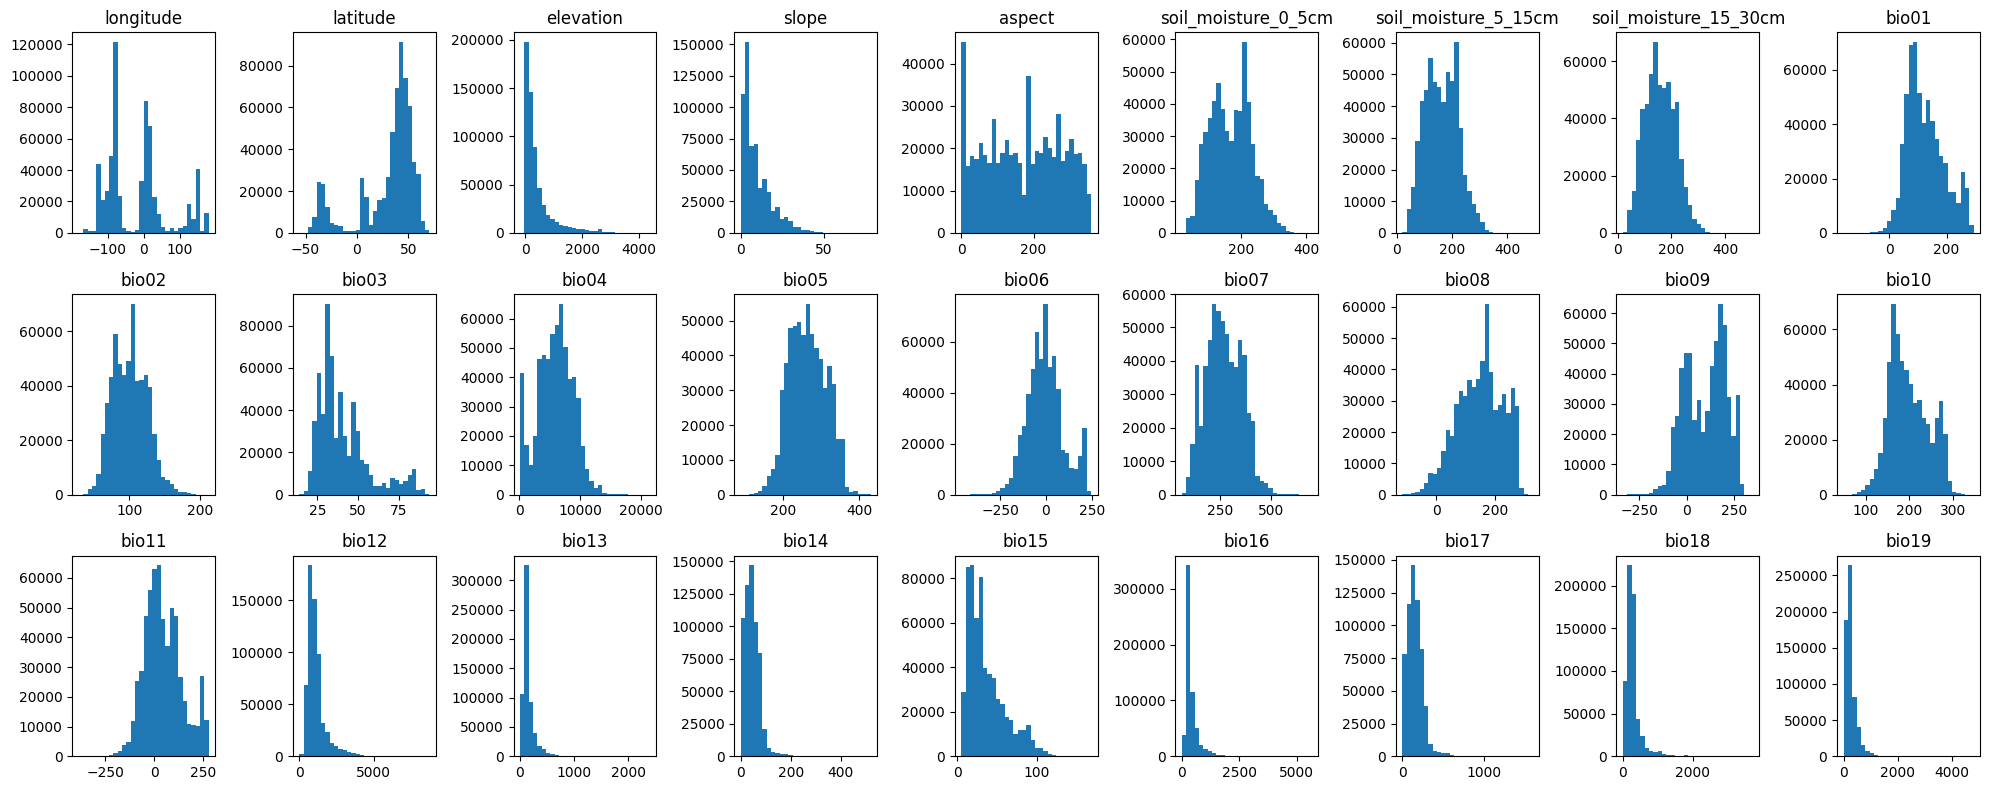

In [49]:
figDist, axDist = plt.subplots(nrows = 3, ncols=9, figsize=(20,8))

for i, col in enumerate(numericCols):
    a = i // 9
    b = i % 9
    ax = axDist[a, b]
    ax.hist(df[col].dropna().values, bins=30)
    ax.set_title(col)

figDist.tight_layout()

## Image Data

In [51]:
# stack all tensors from imgData column via a third dimension
allImgData = torch.stack(list(df['imgData'].values), dim=0)
allImgData.shape

torch.Size([617620, 12, 10])

In [59]:
# flatten 2nd dimension (months) into the first dimension (samples)
allImgDataFlat = allImgData.view(-1, allImgData.shape[2])
allImgDataFlat.shape

torch.Size([7411440, 10])

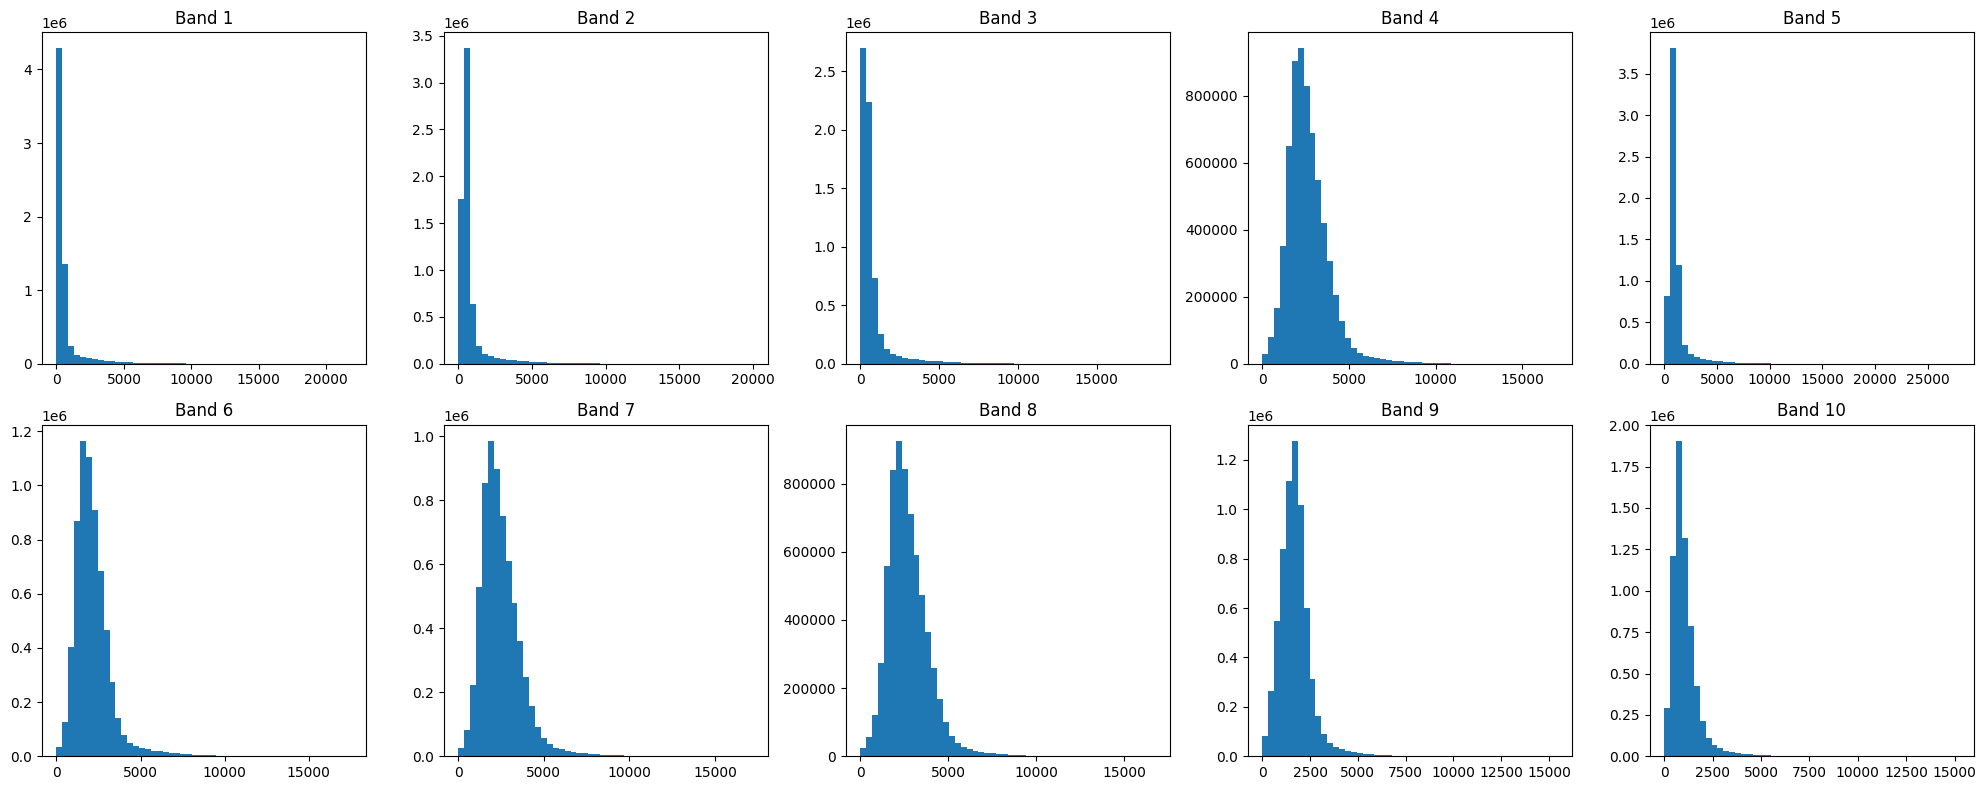

In [61]:
figImgDist, axImgDist = plt.subplots(nrows=2, ncols=5, figsize=(20,8))

for i in range(allImgDataFlat.shape[1]):
    ax = axImgDist[i // 5, i % 5]
    ax.hist(allImgDataFlat[:, i].numpy(), bins=50)
    ax.set_title(f'Band {i+1}')
    #ax.set_xscale('log')

figImgDist.tight_layout()

- Signifcant outliers present